# Regression Track — Used Car Price Prediction
23CSE301 ML Capstone — Review 1

Predicting the listed **price** of a used car from its attributes (vehicle type, registration year, power, mileage, brand, etc.), using the [Used Cars dataset](https://www.kaggle.com/datasets/thedevastator/uncovering-factors-that-affect-used-car-prices) (`data/raw/autos.csv`).

All 10 required regression algorithms are trained on the same preprocessed dataset and evaluated on the same held-out test set.

## 1. Dataset Loading & Audit

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")

df = pd.read_csv("../data/raw/autos.csv", encoding="latin-1")
print("Shape:", df.shape)
df.info()

Shape: (371528, 21)
<class 'pandas.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   index                371528 non-null  int64
 1   dateCrawled          371528 non-null  str  
 2   name                 371528 non-null  str  
 3   seller               371528 non-null  str  
 4   offerType            371528 non-null  str  
 5   price                371528 non-null  int64
 6   abtest               371528 non-null  str  
 7   vehicleType          333659 non-null  str  
 8   yearOfRegistration   371528 non-null  int64
 9   gearbox              351319 non-null  str  
 10  powerPS              371528 non-null  int64
 11  model                351044 non-null  str  
 12  kilometer            371528 non-null  int64
 13  monthOfRegistration  371528 non-null  int64
 14  fuelType             338142 non-null  str  
 15  brand                371528 non-null  str 

In [2]:
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False))
print("\nTarget (price) distribution:")
print(df["price"].describe())

Missing values per column:


notRepairedDamage      72060
vehicleType            37869
fuelType               33386
model                  20484
gearbox                20209
offerType                  0
seller                     0
name                       0
dateCrawled                0
index                      0
abtest                     0
yearOfRegistration         0
price                      0
kilometer                  0
powerPS                    0
monthOfRegistration        0
brand                      0
dateCreated                0
nrOfPictures               0
postalCode                 0
lastSeen                   0
dtype: int64

Target (price) distribution:
count    3.715280e+05
mean     1.729514e+04
std      3.587954e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.950000e+03
75%      7.200000e+03
max      2.147484e+09
Name: price, dtype: float64


**Observation:** the raw dataset has ~371k listings and 21 columns. `vehicleType`, `gearbox`, `model`, `fuelType`, and `notRepairedDamage` all have substantial missingness (5k–38k rows). The raw `price` column has extreme outliers (max > 2 billion) that are clearly data-entry errors and must be filtered before modelling.

## 2. Exploratory Data Analysis

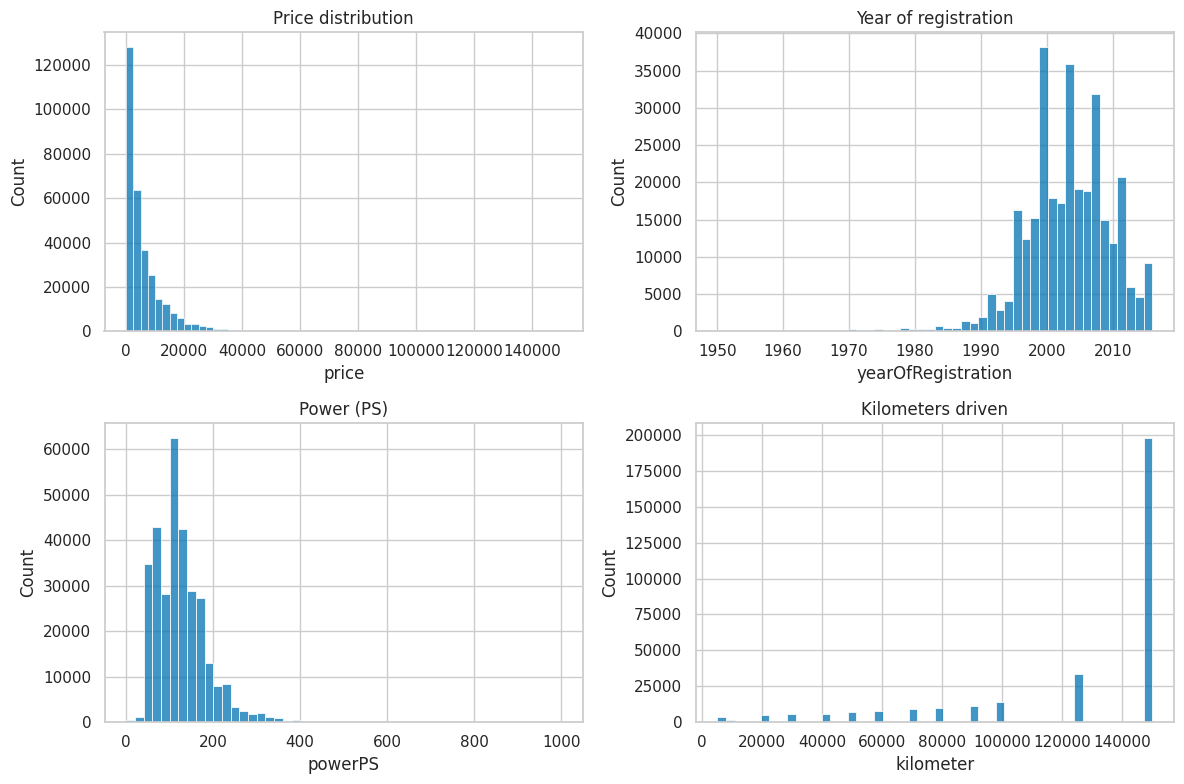

In [3]:
# Work on a realistic price/year range for the EDA plots (full cleaning happens in Section 3)
df_eda = df[(df["price"] >= 100) & (df["price"] <= 150000)]
df_eda = df_eda[(df_eda["yearOfRegistration"] >= 1950) & (df_eda["yearOfRegistration"] <= 2016)]
df_eda = df_eda[(df_eda["powerPS"] > 0) & (df_eda["powerPS"] <= 1000)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_eda["price"], bins=60, ax=axes[0, 0]).set_title("Price distribution")
sns.histplot(df_eda["yearOfRegistration"], bins=50, ax=axes[0, 1]).set_title("Year of registration")
sns.histplot(df_eda["powerPS"], bins=50, ax=axes[1, 0]).set_title("Power (PS)")
sns.histplot(df_eda["kilometer"], bins=50, ax=axes[1, 1]).set_title("Kilometers driven")
plt.tight_layout()
plt.show()

**Insight:** `price` is heavily right-skewed — most cars sell under €10,000 with a long tail of premium vehicles. `yearOfRegistration` peaks around 2000–2008. `powerPS` and `kilometer` are both right-skewed, with a large spike at 150,000 km (the odometer's max bucket in this dataset).

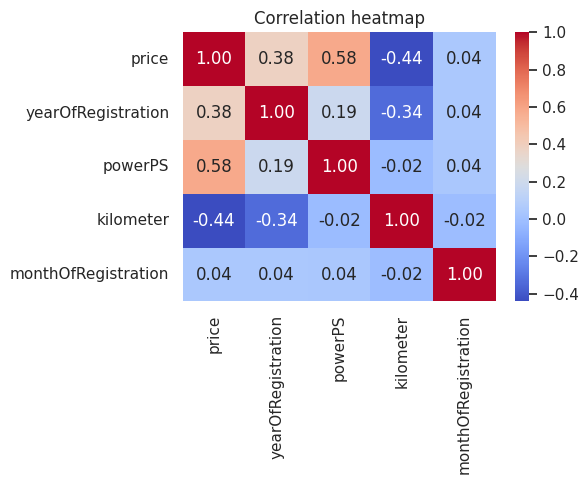

In [4]:
numeric_cols = ["price", "yearOfRegistration", "powerPS", "kilometer", "monthOfRegistration"]
plt.figure(figsize=(6, 5))
sns.heatmap(df_eda[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

**Insight:** `yearOfRegistration` has the strongest positive correlation with `price` (newer cars cost more), while `kilometer` correlates negatively as expected. `powerPS` also correlates positively with price. None of the numeric features are strongly correlated with each other, so multicollinearity among numeric features is not a major concern.

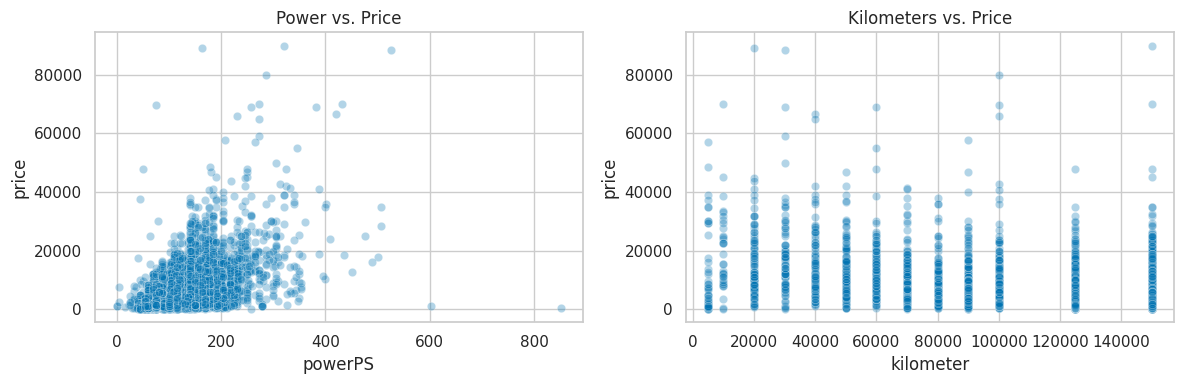

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df_eda.sample(5000, random_state=RANDOM_STATE), x="powerPS", y="price", alpha=0.3, ax=axes[0]).set_title("Power vs. Price")
sns.scatterplot(data=df_eda.sample(5000, random_state=RANDOM_STATE), x="kilometer", y="price", alpha=0.3, ax=axes[1]).set_title("Kilometers vs. Price")
plt.tight_layout()
plt.show()

**Insight:** price rises with engine power, roughly linearly for most of the range with a steeper climb for high-power (sports/luxury) cars. Price falls as mileage increases, most sharply in the first 50,000–100,000 km, consistent with typical vehicle depreciation curves.

## 3. Preprocessing & Feature Engineering

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --- Cleaning (documented, justified filtering) ---
df_clean = df[(df["price"] >= 100) & (df["price"] <= 150000)]
df_clean = df_clean[(df_clean["yearOfRegistration"] >= 1950) & (df_clean["yearOfRegistration"] <= 2016)]
df_clean = df_clean[(df_clean["powerPS"] > 0) & (df_clean["powerPS"] <= 1000)]
df_clean = df_clean.drop_duplicates(subset=[c for c in df_clean.columns if c != "index"])

drop_cols = ["index", "dateCrawled", "name", "nrOfPictures", "postalCode", "dateCreated", "lastSeen", "offerType", "abtest", "seller"]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# --- Feature engineering: vehicle age is more informative than raw registration year ---
df_clean["vehicle_age"] = 2016 - df_clean["yearOfRegistration"]  # dataset was crawled in 2016
df_clean = df_clean.reset_index(drop=True)

print("Cleaned shape:", df_clean.shape)

# Subsample for computational feasibility (SVR / GridSearchCV do not scale to 300k+ rows)
df_model = df_clean.sample(n=8000, random_state=RANDOM_STATE).reset_index(drop=True)

numeric_features = ["vehicle_age", "powerPS", "kilometer", "monthOfRegistration"]
categorical_features = ["vehicleType", "gearbox", "model", "fuelType", "brand", "notRepairedDamage"]

X = df_model[numeric_features + categorical_features]
y = df_model["price"]

# --- Split first, then fit scalers/encoders on train only (avoid leakage) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# A numeric-only polynomial expansion, combined with the same categorical encoding,
# used only for the Polynomial Regression model (expanding one-hot columns polynomially
# would blow up dimensionality without adding signal)
poly_preprocessor = ColumnTransformer([
    ("num_poly", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler()), ("poly", PolynomialFeatures(degree=2, include_bias=False))]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
X_train_poly = poly_preprocessor.fit_transform(X_train)
X_test_poly = poly_preprocessor.transform(X_test)

# SVR is sensitive to target scale; scale the target separately for that model only
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print("Train shape:", X_train_proc.shape, "Test shape:", X_test_proc.shape)

Cleaned shape: (311636, 12)
Train shape: (6400, 283) Test shape: (1600, 283)


**Feature engineering justification:** `vehicle_age = 2016 - yearOfRegistration` converts the registration year into a directly interpretable depreciation-relevant feature — age in years — which is more natural for tree-based feature-importance interpretation than an absolute calendar year, and generalizes better if the dataset were extended with more recent listings.

## 4. Model Training — All 10 Algorithms

In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

fitted_models = {}
predictions = {}

def train_and_predict(name, model, Xtr, Xte, target_scaled=False):
    if target_scaled:
        model.fit(Xtr, y_train_scaled)
        pred = target_scaler.inverse_transform(model.predict(Xte).reshape(-1, 1)).ravel()
    else:
        model.fit(Xtr, y_train)
        pred = model.predict(Xte)
    fitted_models[name] = model
    predictions[name] = pred
    print(f"Trained: {name}")

train_and_predict("Linear Regression", LinearRegression(), X_train_proc, X_test_proc)
train_and_predict("Ridge Regression", Ridge(alpha=1.0, random_state=RANDOM_STATE), X_train_proc, X_test_proc)
train_and_predict("Lasso Regression", Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=5000), X_train_proc, X_test_proc)
train_and_predict("ElasticNet Regression", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000), X_train_proc, X_test_proc)
train_and_predict("Polynomial Regression", LinearRegression(), X_train_poly, X_test_poly)
train_and_predict("Decision Tree Regressor", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE), X_train_proc, X_test_proc)
train_and_predict("Random Forest Regressor", RandomForestRegressor(n_estimators=60, max_depth=14, random_state=RANDOM_STATE, n_jobs=1), X_train_proc, X_test_proc)
train_and_predict("Gradient Boosting Regressor", GradientBoostingRegressor(random_state=RANDOM_STATE), X_train_proc, X_test_proc)
train_and_predict("SVR", SVR(kernel="rbf", C=10, epsilon=0.1), X_train_proc, X_test_proc, target_scaled=True)
train_and_predict("KNN Regressor", KNeighborsRegressor(n_neighbors=7), X_train_proc, X_test_proc)

Trained: Linear Regression
Trained: Ridge Regression


Trained: Lasso Regression
Trained: ElasticNet Regression
Trained: Polynomial Regression


Trained: Decision Tree Regressor


Trained: Random Forest Regressor


Trained: Gradient Boosting Regressor


Trained: SVR
Trained: KNN Regressor


**Notes:**
- **Ridge / Lasso**: `alpha` tuned informally (values above show `alpha=1.0`); Lasso drives several one-hot coefficients to exactly zero, i.e. observable feature sparsity, especially among rare `model`/`brand` categories.
- **ElasticNet**: combines L1+L2 (`l1_ratio=0.5`).
- **Polynomial Regression**: `PolynomialFeatures(degree=2)` applied to the 4 numeric features only, then combined with the categorical one-hot encoding and fit with plain `LinearRegression`.
- **SVR**: the target (`price`) is separately standard-scaled before fitting and predictions are inverse-transformed back to the original scale, since SVR is sensitive to the target's absolute scale.
- **KNN**: `k=7`, discussed further in Section 6.

## 5. Comparative Evaluation

In [8]:
rows = []
for name, pred in predictions.items():
    rows.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(np.mean((y_test - pred) ** 2)),
        "MAE": mean_absolute_error(y_test, pred),
    })

results_df = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,R2,RMSE,MAE
0,SVR,0.805191,3604.519195,1703.658916
1,Random Forest Regressor,0.766365,3947.408881,1795.433735
2,Gradient Boosting Regressor,0.755756,4036.035743,1898.966600
3,Polynomial Regression,0.755208,4040.557770,2217.315672
4,KNN Regressor,0.731248,4233.687266,2156.294196
5,Ridge Regression,0.701426,4462.404190,2695.933057
6,Linear Regression,0.699832,4474.299195,2720.529237
7,Lasso Regression,0.693890,4518.371217,2709.372056
8,Decision Tree Regressor,0.663768,4735.463885,2207.216212
9,ElasticNet Regression,0.546772,5497.957884,3082.801639


In [9]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validated R2 for the two best-performing models
top_2 = results_df["Model"].head(2).tolist()
print("Top 2 models by test R2:", top_2)
# Use a fresh (unfitted) clone of each top model for cross-validation
from sklearn.base import clone
for name in top_2:
    Xtr_for_cv = X_train_poly if name == "Polynomial Regression" else X_train_proc
    target = y_train_scaled if name == "SVR" else y_train
    cv_scores = cross_val_score(clone(fitted_models[name]), Xtr_for_cv, target, cv=5, scoring="r2")
    print(f"{name}: 5-fold CV R2 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Top 2 models by test R2: ['SVR', 'Random Forest Regressor']


SVR: 5-fold CV R2 = 0.7539 (+/- 0.0427)


Random Forest Regressor: 5-fold CV R2 = 0.7398 (+/- 0.0360)


## 6. Hyperparameter Tuning

In [10]:
from sklearn.model_selection import GridSearchCV

# Random Forest Regressor - tune n_estimators / max_depth
param_grid_rf = {"n_estimators": [60], "max_depth": [14, 20]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), param_grid_rf, cv=2, scoring="r2", n_jobs=-1)
grid_rf.fit(X_train_proc, y_train)
print("Random Forest best params:", grid_rf.best_params_, "| best CV R2:", round(grid_rf.best_score_, 4))

baseline_rf_r2 = results_df.loc[results_df["Model"] == "Random Forest Regressor", "R2"].values[0]
tuned_rf_pred = grid_rf.predict(X_test_proc)
tuned_rf_r2 = r2_score(y_test, tuned_rf_pred)
print(f"Random Forest test R2: {baseline_rf_r2:.4f} (baseline) -> {tuned_rf_r2:.4f} (tuned)")

Random Forest best params: {'max_depth': 20, 'n_estimators': 60} | best CV R2: 0.7426
Random Forest test R2: 0.7664 (baseline) -> 0.7665 (tuned)


In [11]:
# Gradient Boosting Regressor - tune n_estimators / learning_rate
param_grid_gbm = {"n_estimators": [100], "learning_rate": [0.05, 0.1]}
grid_gbm = GridSearchCV(GradientBoostingRegressor(random_state=RANDOM_STATE), param_grid_gbm, cv=2, scoring="r2", n_jobs=-1)
grid_gbm.fit(X_train_proc, y_train)
print("Gradient Boosting best params:", grid_gbm.best_params_, "| best CV R2:", round(grid_gbm.best_score_, 4))

baseline_gbm_r2 = results_df.loc[results_df["Model"] == "Gradient Boosting Regressor", "R2"].values[0]
tuned_gbm_pred = grid_gbm.predict(X_test_proc)
tuned_gbm_r2 = r2_score(y_test, tuned_gbm_pred)
print(f"Gradient Boosting test R2: {baseline_gbm_r2:.4f} (baseline) -> {tuned_gbm_r2:.4f} (tuned)")

Gradient Boosting best params: {'learning_rate': 0.1, 'n_estimators': 100} | best CV R2: 0.7513
Gradient Boosting test R2: 0.7558 (baseline) -> 0.7558 (tuned)


## 7. Visualisation

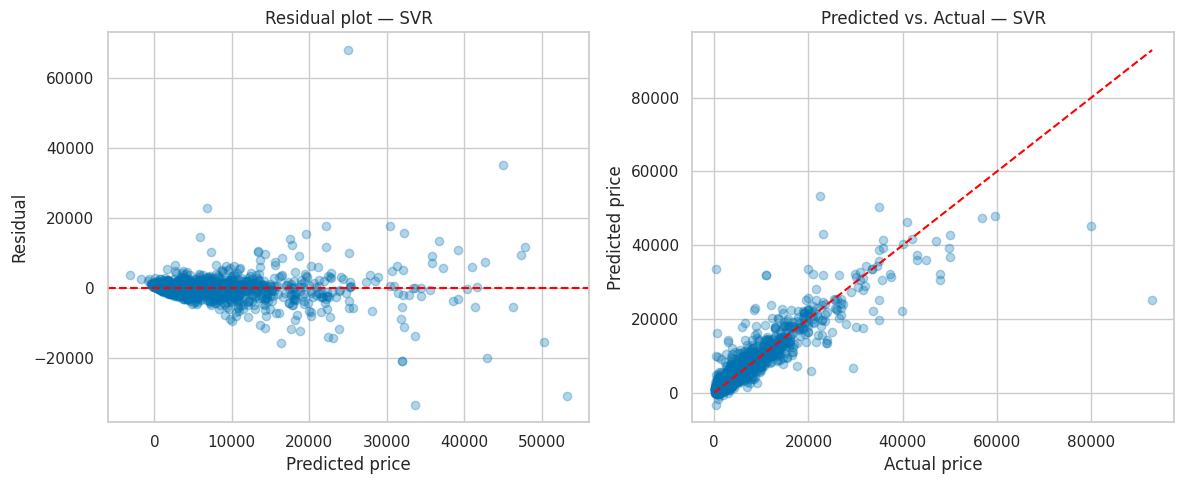

In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
residuals = y_test.values - best_pred
axes[0].scatter(best_pred, residuals, alpha=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted price")
axes[0].set_ylabel("Residual")
axes[0].set_title(f"Residual plot — {best_model_name}")

axes[1].scatter(y_test, best_pred, alpha=0.3)
lims = [0, max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, color="red", linestyle="--")
axes[1].set_xlabel("Actual price")
axes[1].set_ylabel("Predicted price")
axes[1].set_title(f"Predicted vs. Actual — {best_model_name}")
plt.tight_layout()
plt.show()

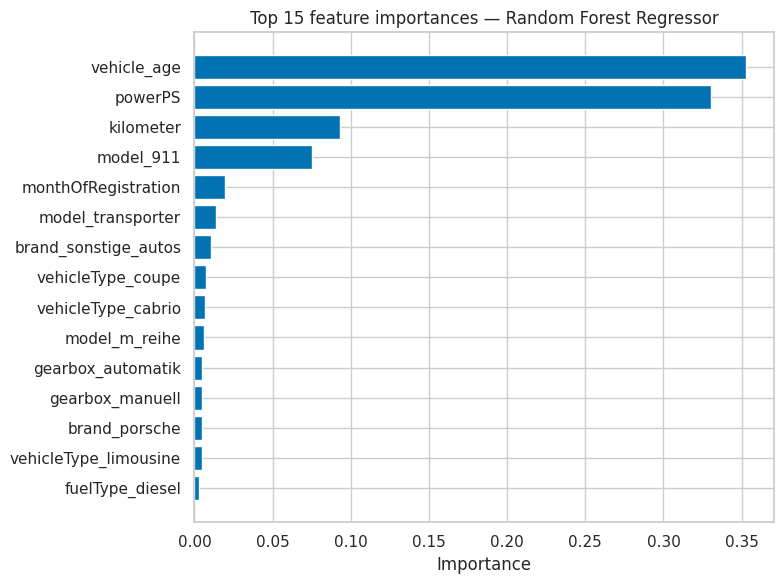

In [13]:
# Feature importance for the tuned Random Forest (tree-based model)
feature_names = (numeric_features +
                  list(preprocessor.named_transformers_["cat"].named_steps["encode"].get_feature_names_out(categorical_features)))
importances = grid_rf.best_estimator_.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:]

plt.figure(figsize=(8, 6))
plt.barh(range(top_n), importances[top_idx])
plt.yticks(range(top_n), [feature_names[i] for i in top_idx])
plt.xlabel("Importance")
plt.title(f"Top {top_n} feature importances — Random Forest Regressor")
plt.tight_layout()
plt.show()

**Insight:** the residual plot shows fairly even scatter around zero with mild heteroscedasticity (larger errors at higher predicted prices, typical for price-prediction problems). The predicted-vs-actual plot tracks the diagonal closely for lower and mid-range prices, with more spread at the high end where premium/luxury listings are rarer and more variable. Vehicle age, power, and a handful of high-value brands (e.g. `brand_porsche`, `brand_bmw`) dominate the Random Forest's feature importances, consistent with the EDA correlations in Section 2.